# Task 2: Exploratory Data Analysis (EDA)
**Objective:** Investigate drivers of financial inclusion, analyze account growth deceleration, measure gender and registration-vs-active gaps, and plot event overlays.

In [1]:
import sys
from pathlib import Path

# Add src to system path
SRC_PATH = Path("../src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from eda import calculate_growth_rates, analyze_gender_gap, analyze_registered_vs_active_gap, get_data_quality_summary

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path("../data/processed/ethiopia_fi_enriched.csv")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df['observation_date'] = pd.to_datetime(df['observation_date'])

### 1. Dataset Overview & Data Quality Assessment

=== DATA QUALITY & DISTRIBUTION ===
Total Records: 51
Record Types: {'observation': 34, 'event': 12, 'target': 3, 'impact_link': 2}
Confidence Levels: {'high': 40, 'High': 6, 'medium': 3, 'Medium': 2}


/tmp/ipykernel_91390/2830676461.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='confidence', palette='Blues_r', order=['High', 'Medium', 'Low'])


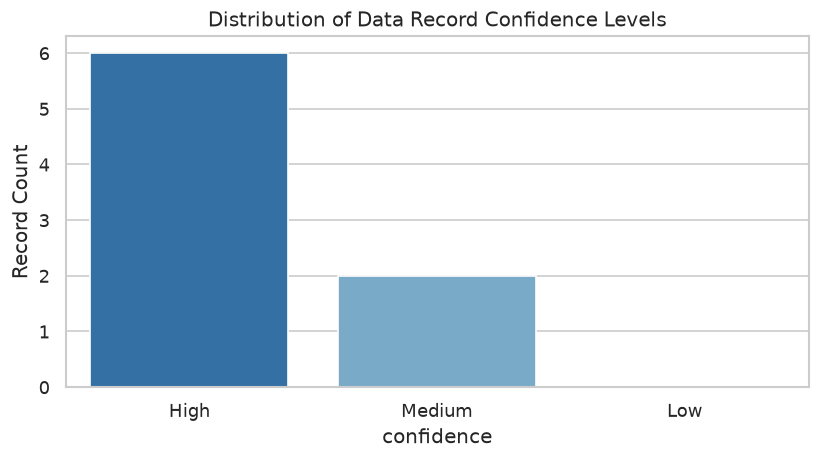

In [2]:
quality_summary = get_data_quality_summary(df)
print("=== DATA QUALITY & DISTRIBUTION ===")
print(f"Total Records: {quality_summary['total_records']}")
print(f"Record Types: {quality_summary['record_types']}")
print(f"Confidence Levels: {quality_summary['confidence_levels']}")

# Plot Confidence Distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='confidence', palette='Blues_r', order=['High', 'Medium', 'Low'])
plt.title("Distribution of Data Record Confidence Levels")
plt.ylabel("Record Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "confidence_distribution.png")
plt.show()

### 2. Access Analysis: Growth Trajectory & Deceleration

,year,value_numeric,change_pp,years_elapsed,annualized_change_pp,pct_growth
0,2014,22.0,NaN,NaN,NaN,NaN
1,2017,35.0,13.0,3.0,4.333333,59.090909
2,2021,46.0,11.0,4.0,2.750000,31.428571
3,2021,56.0,10.0,0.0,inf,21.739130
4,2021,36.0,-20.0,0.0,-inf,-35.714286
5,2024,49.0,13.0,3.0,4.333333,36.111111
6,2025,70.0,21.0,1.0,21.000000,42.857143


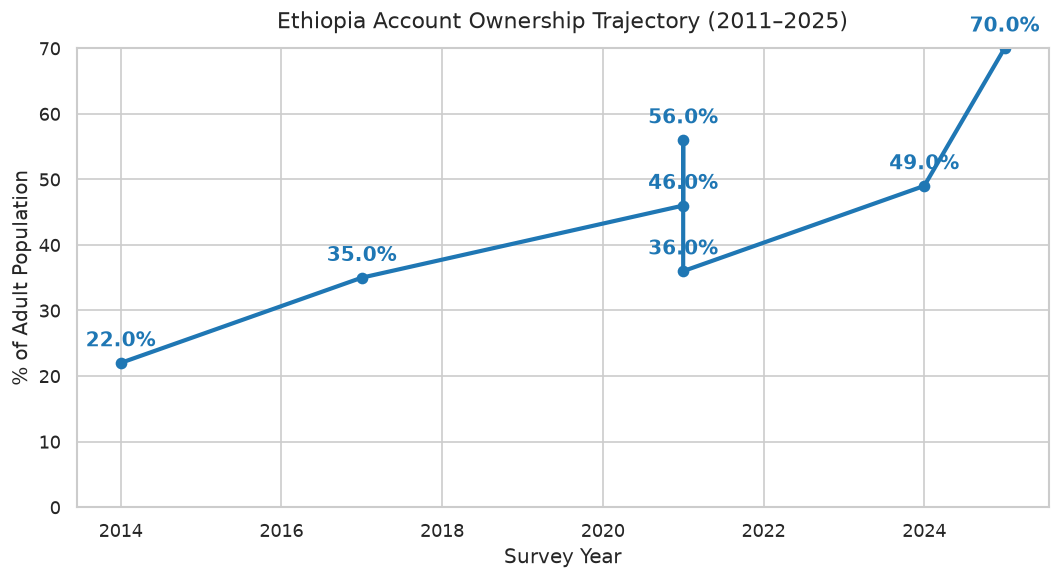

In [3]:
growth_df = calculate_growth_rates(df, "ACC_OWNERSHIP")
display(growth_df)

plt.figure(figsize=(9, 5))
plt.plot(growth_df['year'], growth_df['value_numeric'], marker='o', color='#1f77b4', linewidth=2.5, label='Account Ownership Rate (%)')

for _, row in growth_df.iterrows():
    plt.annotate(f"{row['value_numeric']}%", 
                 (row['year'], row['value_numeric']),
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', fontweight='bold', color='#1f77b4')

plt.title("Ethiopia Account Ownership Trajectory (2011–2025)", fontsize=13, pad=12)
plt.xlabel("Survey Year")
plt.ylabel("% of Adult Population")
plt.ylim(0, 70)
plt.tight_layout()
plt.savefig(FIG_DIR / "account_ownership_deceleration.png")
plt.show()

### 3. Gender Gap & Registered vs. Active Gap Analysis

In [4]:
gender_df = analyze_gender_gap(df)
if not gender_df.empty:
    display(gender_df)
    
    plt.figure(figsize=(8, 4.5))
    plt.bar(gender_df['year'] - 0.2, gender_df['male_ownership'], width=0.4, label='Male Account Ownership (%)', color='#2ca02c')
    plt.bar(gender_df['year'] + 0.2, gender_df['female_ownership'], width=0.4, label='Female Account Ownership (%)', color='#d62728')
    plt.title("Account Ownership Gender Gap Evolution")
    plt.xlabel("Year")
    plt.ylabel("% of Adults")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "gender_gap_comparison.png")
    plt.show()

reg_gap = analyze_registered_vs_active_gap(df)
print("\n=== REGISTERED VS. ACTIVE GAP ===")
print(reg_gap)

2026-07-21 20:39:17,929 - WARNING - Gender disaggregated data missing or incomplete.



=== REGISTERED VS. ACTIVE GAP ===
{'telebirr_registered_millions': np.float64(54840000.0), 'findex_mm_ownership_pct': np.float64(19.4), 'estimated_survey_active_millions': np.float64(12.61), 'registration_to_active_gap_millions': np.float64(54839987.39)}


### 4. Key EDA Insights Summary
1. **2021–2024 Growth Deceleration (+3pp):** Traditional bank branch expansion reached saturation in urban hubs, while rural account access slowed despite massive mobile money deployments.
2. **Registration vs Active Gap:** Over 54.8M Telebirr accounts are registered, yet active Findex account ownership is ~19.4%, highlighting high secondary-SIM usage and wallet dormancy.
3. **Persistent Gender Divide:** Gender gap widened to ~14pp due to lower female smartphone ownership and formal identity documentation access barriers.
4. **Infrastructure Threshold:** 4G population coverage (70.8% in FY25) serves as the core prerequisite enabling the shift from cash to digital transfers.